# HMM市场状态预测

## 分钟频次的市场状态预测

# 1.数据准备

## 1.1 观察数据

In [18]:
#导包
import pandas as pd
import numpy as np
from hmmlearn import hmm
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import mode

In [19]:
df_min = pd.read_csv('../data/kline_im.csv')
df_min.set_index('DateTime', inplace=True)
df_min

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,max_ret_index,min_ret_index,max_amount_index,increase_kline_ratio,decrease_kline_ratio,equal_kline_ratio,vwap_ema_1,vwap_ema_2,pct,slippage
DateTime,,,,,,,,,,,,,,,,,,,,,
2022/7/22 9:30,0,2022/7/22,5041.799985,5076.999985,5032.799985,5047.599985,2597,3670919280,5062.106651,0.514591,...,1,13,0,0.533333,0.400000,0.066667,1.411248e+06,1.413470e+06,-0.011966,1.981140e-07
2022/7/22 9:45,1,2022/7/22,5048.199985,5048.599985,4976.799985,4987.199985,2292,3214320560,5001.066651,0.973886,...,7,2,5,0.200000,0.800000,0.000000,1.399274e+06,1.402205e+06,0.003930,2.005133e-07
2022/7/22 10:00,2,2022/7/22,4987.199985,5016.199985,4984.399985,5006.799985,1422,1994239360,5004.039985,0.818966,...,0,13,13,0.666667,0.266667,0.066667,1.403338e+06,1.402740e+06,0.006551,1.997284e-07
2022/7/22 10:15,3,2022/7/22,5008.199985,5045.599985,5000.799985,5039.599985,1392,1957681760,5022.933318,1.042818,...,10,0,11,0.666667,0.333333,0.000000,1.408995e+06,1.406698e+06,-0.003730,1.984284e-07
2022/7/22 10:30,4,2022/7/22,5039.399985,5039.599985,5016.799985,5020.799985,1118,1572904440,5025.826651,1.083749,...,3,2,11,0.333333,0.666667,0.000000,1.406104e+06,1.406730e+06,-0.005577,1.991714e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026/3/20 13:45,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567,...,8,9,1,0.400000,0.600000,0.000000,1.529395e+06,1.530344e+06,-0.001465,1.308250e-07
2026/3/20 14:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320,...,6,8,9,0.400000,0.533333,0.066667,1.526780e+06,1.528041e+06,-0.000524,1.310170e-07
2026/3/20 14:15,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,0.822899,...,2,4,2,0.466667,0.533333,0.000000,1.525637e+06,1.526077e+06,-0.002779,1.310857e-07


## 1.2 特征工程

选择5个特征

In [20]:
# im_model
# 一日对数成交量差
df_min['vol_log_ret_1p'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(1))

# 五日对数成交量差
df_min['vol_log_ret_5p'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(5))

# 一日对数收盘价差 (当日收益率)
df_min['close_log_ret_1p'] = np.log(df_min['close']) - np.log(df_min['close'].shift(1))

# 五日对数收盘价差 (五日动量)
df_min['close_log_ret_5p'] = np.log(df_min['close']) - np.log(df_min['close'].shift(5))

# 当日对数高低价差 (当日内波动)
df_min['intraday_range_log'] = np.log(df_min['high']) - np.log(df_min['low'])
# 删除前五行数据（滑窗）
df_min = df_min.drop(df_min.index[:5])
df_min.index = pd.to_datetime(df_min.index)
df_min[:15]

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,equal_kline_ratio,vwap_ema_1,vwap_ema_2,pct,slippage,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-07-22 10:45:00,5,2022/7/22,5021.399985,5021.399985,4990.999985,4992.799985,1019,1429435160,5005.079985,0.809127,...,0.000000,1.401266e+06,1.402722e+06,-0.000881,2.002884e-07,-0.092720,-0.935535,-0.005592,-0.010916,0.006072
2022-07-22 11:00:00,6,2022/7/22,4994.199985,5006.599985,4986.199985,4988.399985,778,1089874960,4996.893318,0.847811,...,0.000000,1.399397e+06,1.400484e+06,-0.011306,2.004651e-07,-0.269851,-1.080454,-0.000882,0.000241,0.004083
2022-07-22 11:15:00,7,2022/7/22,4986.399985,4986.399985,4915.999985,4931.999985,1399,1948265560,4956.306651,0.787778,...,0.000000,1.387922e+06,1.392623e+06,0.006772,2.027575e-07,0.586786,-0.016307,-0.011371,-0.015052,0.014219
2022-07-22 13:00:00,8,2022/7/22,4931.599985,4965.599985,4930.999985,4965.399985,1068,1486543960,4953.679985,0.760959,...,0.066667,1.394292e+06,1.392349e+06,-0.003263,2.013936e-07,-0.269970,-0.264954,0.006749,-0.014833,0.006992
2022-07-22 13:15:00,9,2022/7/22,4963.799985,4965.199985,4936.599985,4949.199985,717,998363960,4953.693318,0.788164,...,0.000000,1.390280e+06,1.391911e+06,-0.014467,2.020529e-07,-0.398467,-0.444221,-0.003268,-0.014363,0.005777
2022-07-22 13:30:00,10,2022/7/22,4949.199985,4949.199985,4876.999985,4877.599985,2331,3221942640,4903.893318,1.055265,...,0.000000,1.378458e+06,1.382542e+06,0.005207,2.050189e-07,1.178977,0.827476,-0.014573,-0.023344,0.014696
2022-07-22 13:45:00,11,2022/7/22,4878.599985,4903.799985,4848.799985,4902.999985,1487,2047987280,4879.306651,0.662796,...,0.000000,1.381554e+06,1.377962e+06,-0.003100,2.039568e-07,-0.449537,0.647789,0.005194,-0.017268,0.011279
2022-07-22 14:00:00,12,2022/7/22,4903.599985,4911.799985,4877.799985,4887.799985,937,1293448360,4892.346651,0.939495,...,0.133333,1.379586e+06,1.379965e+06,0.006301,2.045910e-07,-0.461833,-0.400830,-0.003105,-0.009002,0.006946
2022-07-22 14:15:00,13,2022/7/22,4886.999985,4918.599985,4874.999985,4918.599985,1099,1517120120,4894.573318,0.911313,...,0.000000,1.384542e+06,1.380977e+06,0.009190,2.033099e-07,0.159473,0.028613,0.006282,-0.009470,0.008904


## 1.3 特征标准化

### 1.3.1 正常训练--测试

In [21]:

# window = 336
# features = ['vol_log_ret_1p','vol_log_ret_5p','close_log_ret_1p','close_log_ret_5p','intraday_range_log']
# # 计算滚动均值和滚动标准差
# rolling_mean = df_min[features].rolling(window=window).mean()
# rolling_std = df_min[features].rolling(window=window).std()


# # 执行滚动标准化
# # 前 251 行会因为窗口不足产生 NaN
# df_feature_rolling = (df_min[features] - rolling_mean) / rolling_std
# df_train_norm = df_feature_rolling.loc[:'2024-09-30 15:00'].dropna()
# df_test_norm = df_feature_rolling.loc['2024-10-01 09:30':]
# X_train = df_train_norm
# X_test = df_test_norm


### 1.3.2 交叉验证

In [22]:
import pandas as pd

# 设定窗口
window = 336
features = ['vol_log_ret_1p','vol_log_ret_5p','close_log_ret_1p','close_log_ret_5p','intraday_range_log']

# 定义两个时间段
period_A_start, period_A_end = '2022-07-22 09:30', '2024-09-30 15:00'
period_B_start, period_B_end = '2024-10-01 09:30', '2026-3-20 14:45'

# 如果你想用 Period B 训练，Period A 测试：
train_raw = df_min.loc[period_B_start : period_B_end]
test_raw = df_min.loc[period_A_start : period_A_end]

def get_norm_data(df, features, window):
    # 局部计算滚动指标，避免利用另一段数据的信息
    rolling_mean = df[features].rolling(window=window).mean()
    rolling_std = df[features].rolling(window=window).std()
    return ((df[features] - rolling_mean) / rolling_std).dropna()

X_train = get_norm_data(train_raw, features, window)
X_test = get_norm_data(test_raw, features, window)

In [23]:
# 过滤出原表
df_train_rolling = df_min.loc[X_train.index]
df_test_rolling = df_min.loc[X_test.index]
df_train_rolling

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,equal_kline_ratio,vwap_ema_1,vwap_ema_2,pct,slippage,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-11-05 14:45:00,8863,2024/11/5,5206.599998,5208.199998,5184.399998,5205.799998,10649,13321763720,5200.493332,0.531908,...,0.000000,1.252153e+06,1.251203e+06,0.001076,1.920934e-07,-0.075750,0.186405,-0.000154,-0.001459,0.004580
2024-11-06 09:30:00,8864,2024/11/6,5211.399998,5259.399998,5162.999998,5211.399998,29987,37603745160,5219.386665,0.888864,...,0.000000,1.252745e+06,1.253099e+06,0.007100,1.918870e-07,1.035298,1.614855,0.001075,0.002998,0.018499
2024-11-06 09:45:00,8865,2024/11/6,5210.799998,5253.599998,5206.799998,5248.399998,14345,18035192720,5232.373332,0.876522,...,0.066667,1.260400e+06,1.257979e+06,0.000305,1.905343e-07,-0.737363,0.119283,0.007075,0.012192,0.008948
2024-11-06 10:00:00,8866,2024/11/6,5248.999998,5293.199998,5240.999998,5249.999998,20637,26094252120,5267.013332,0.901958,...,0.000000,1.260908e+06,1.263791e+06,0.000648,1.904762e-07,0.363684,1.088344,0.000305,0.008224,0.009911
2024-11-06 10:15:00,8867,2024/11/6,5251.199998,5265.199998,5227.999998,5253.399998,11028,13902001760,5249.346665,0.870713,...,0.000000,1.262298e+06,1.261223e+06,-0.002322,1.903529e-07,-0.626648,-0.040778,0.000647,0.008948,0.007090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20 13:45:00,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567,...,0.000000,1.529395e+06,1.530344e+06,-0.001465,1.308250e-07,0.074489,-0.393088,-0.002091,-0.008338,0.003162
2026-03-20 14:00:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320,...,0.066667,1.526780e+06,1.528041e+06,-0.000524,1.310170e-07,0.193972,-0.676988,-0.001466,-0.016863,0.005127
2026-03-20 14:15:00,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,0.822899,...,0.000000,1.525637e+06,1.526077e+06,-0.002779,1.310857e-07,-0.247713,-0.534450,-0.000524,-0.010769,0.003197


# 2.模型算法

## 2.1 HMM模型训练

In [24]:

X_train = X_train.values
X_test = X_test.values
# 训练模型
model = hmm.GaussianHMM(n_components=4, 
                        covariance_type="full", 
                        n_iter=1000, 
                        random_state=42)

model.fit(X_train)
df_train_plot = df_train_rolling.copy() 
df_test_plot = df_test_rolling.copy()   
df_train_plot['state'] = model.predict(X_train)
df_test_plot['state'] = model.predict(X_test)

kmeans迭代次数： 10


In [25]:
# # 滑动平滑处理——20个窗口，众数
# def smooth_state_mode(states, window):
#     s = pd.Series(states)
#     # lambda 函数计算窗口内的众数
#     smoothed = s.rolling(window=window, min_periods=1).apply(
#         lambda x: mode(x)[0]
#     )
#     # 前 20 个保持原始预测
#     smoothed.iloc[:window] = s.iloc[:window]
    
#     return smoothed.astype(int).values
# train_raw = df_train_plot['state'].values
# test_raw = df_test_plot['state'].values
# df_train_plot['state'] = smooth_state_mode(train_raw, 2)
# df_test_plot['state'] = smooth_state_mode(test_raw, 2)
df_test_plot['state'][110:140]

DateTime
2022-08-31 10:00:00    3
2022-08-31 10:15:00    3
2022-08-31 10:30:00    3
2022-08-31 10:45:00    3
2022-08-31 11:00:00    1
2022-08-31 11:15:00    1
2022-08-31 13:00:00    1
2022-08-31 13:15:00    3
2022-08-31 13:30:00    3
2022-08-31 13:45:00    3
2022-08-31 14:00:00    3
2022-08-31 14:15:00    3
2022-08-31 14:30:00    3
2022-08-31 14:45:00    3
2022-09-01 09:30:00    3
2022-09-01 09:45:00    3
2022-09-01 10:00:00    3
2022-09-01 10:15:00    3
2022-09-01 10:30:00    3
2022-09-01 10:45:00    3
2022-09-01 11:00:00    1
2022-09-01 11:15:00    1
2022-09-01 13:00:00    1
2022-09-01 13:15:00    1
2022-09-01 13:30:00    1
2022-09-01 13:45:00    1
2022-09-01 14:00:00    1
2022-09-01 14:15:00    1
2022-09-01 14:30:00    1
2022-09-01 14:45:00    1
Name: state, dtype: int64

# 3 回测可视化分析

## 3.1 训练集状态分类情况
分四个状态效果最好

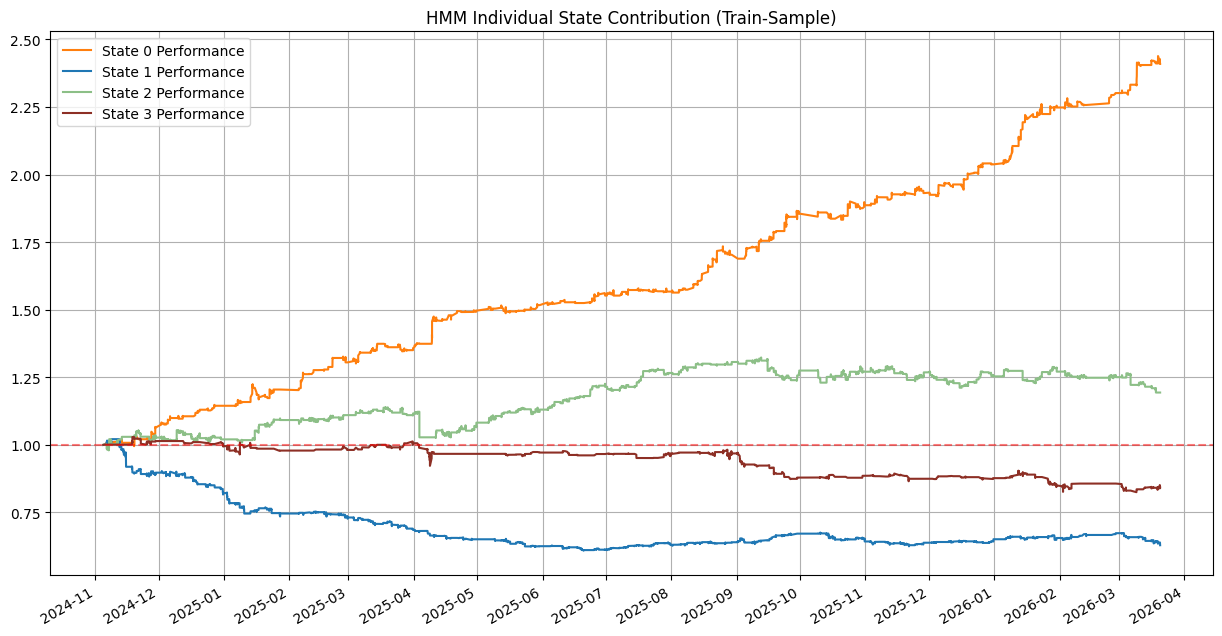

In [26]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(model.n_components):
    df_train_sample = df_train_plot.copy()
    net = df_train_sample['pct'].astype(float).values
    signal = (df_train_sample['state'] == i).astype(float).values
    # 计算策略收益序列
    strat_ret = net * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = net[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_train_sample.index[1] - df_train_sample.index[0] # 计算时间间隔
    plot_dates = [df_train_sample.index[0] - time_delta] + list(df_train_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Train-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 3.2 测试集状态分类

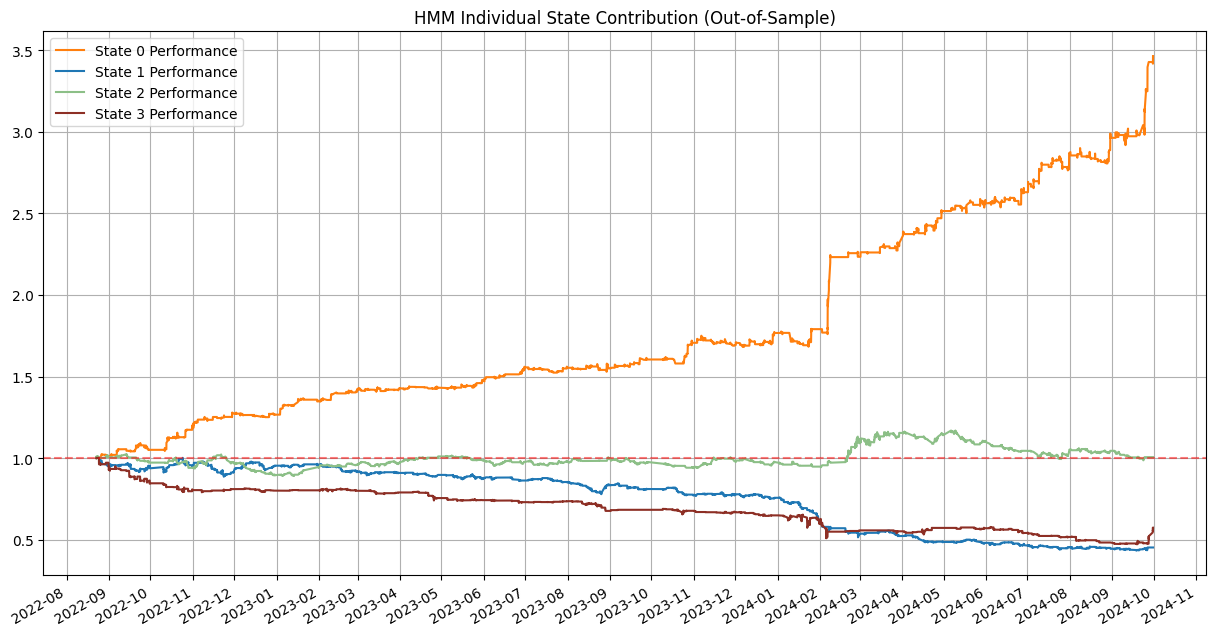

In [27]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(model.n_components):
    df_test_sample = df_test_plot.copy()
    
    df_test_sample['signal'] = (df_test_plot['state'] == i).shift(1).fillna(0).astype(float)

    # 计算策略收益序列
    f3_vals = df_test_sample['close_log_ret_1p'].astype(float).values
    signal = df_test_sample['signal'].astype(float).values
    strat_ret = f3_vals * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = f3_vals[0]

    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_test_sample.index[1] - df_test_sample.index[0] # 计算时间间隔
    plot_dates = [df_test_sample.index[0] - time_delta] + list(df_test_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Out-of-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 3.3 收益回测评估

In [ ]:
# 计算最大回撤
def calculate_mdd(cum_series):
    """
    计算净值曲线的最大回撤及其结束时间点
    """
    # 转换为 numpy 数组方便计算
    nav = np.array(cum_series)
    # 计算历史滚动最高点
    peaks = np.maximum.accumulate(nav)
    # 计算回撤序列 (当前值 / 历史最高值 - 1)
    drawdowns = (nav - peaks)
    # 找到最大回撤值（最小值）
    mdd_value = np.min(drawdowns)
    # 找到最大回撤发生的索引位置（即回撤结束/最低点的位置）
    mdd_idx = np.argmin(drawdowns)
    
    return mdd_value, mdd_idx

In [29]:
# 算上换手率
def cal_net_values(post:np.array,ret:np.array) -> np.array:
    '''计算净值序列
    pos: 仓位
    ret:未来1个周期的收益率'''
    fee = 0.0005 # 仓位每次变动的磨损
    position_changes = np.hstack((post[0],np.diff(post)))# 拼接初始仓位并记录此时的手续费，后面的时间使用diff的
    ret_array = post*ret - abs(position_changes*fee)
    net_values = 1+(ret_array).cumsum()
    return net_values, ret_array  # 返回净值序列、收益率序列

In [30]:
# 夏普计算
def calculate_sharpe(strat_ret, rf=0, periods=252):
    '''
    strat_ret: 策略收益率序列
    rf: 无风险利率 (年化)（市场的年化收益率）
    periods: 年度交易周期数 
    '''
    # 计算超额收益 (Daily Excess Return)
    excess_ret = strat_ret - (rf / periods)
    
    # 计算均值和标准差
    mean_ret = np.mean(excess_ret)
    std_ret = np.std(excess_ret)
    
    # 计算原始夏普 (非年化)
    if std_ret == 0:
        return 0
    sharpe = mean_ret / std_ret
    
    # 年化处理
    annual_sharpe = sharpe * np.sqrt(periods)
    
    return annual_sharpe


In [31]:
df_train_plot

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,vwap_ema_1,vwap_ema_2,pct,slippage,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log,state
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-11-05 14:45:00,8863,2024/11/5,5206.599998,5208.199998,5184.399998,5205.799998,10649,13321763720,5200.493332,0.531908,...,1.252153e+06,1.251203e+06,0.001076,1.920934e-07,-0.075750,0.186405,-0.000154,-0.001459,0.004580,2
2024-11-06 09:30:00,8864,2024/11/6,5211.399998,5259.399998,5162.999998,5211.399998,29987,37603745160,5219.386665,0.888864,...,1.252745e+06,1.253099e+06,0.007100,1.918870e-07,1.035298,1.614855,0.001075,0.002998,0.018499,0
2024-11-06 09:45:00,8865,2024/11/6,5210.799998,5253.599998,5206.799998,5248.399998,14345,18035192720,5232.373332,0.876522,...,1.260400e+06,1.257979e+06,0.000305,1.905343e-07,-0.737363,0.119283,0.007075,0.012192,0.008948,0
2024-11-06 10:00:00,8866,2024/11/6,5248.999998,5293.199998,5240.999998,5249.999998,20637,26094252120,5267.013332,0.901958,...,1.260908e+06,1.263791e+06,0.000648,1.904762e-07,0.363684,1.088344,0.000305,0.008224,0.009911,2
2024-11-06 10:15:00,8867,2024/11/6,5251.199998,5265.199998,5227.999998,5253.399998,11028,13902001760,5249.346665,0.870713,...,1.262298e+06,1.261223e+06,-0.002322,1.903529e-07,-0.626648,-0.040778,0.000647,0.008948,0.007090,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20 13:45:00,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567,...,1.529395e+06,1.530344e+06,-0.001465,1.308250e-07,0.074489,-0.393088,-0.002091,-0.008338,0.003162,1
2026-03-20 14:00:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320,...,1.526780e+06,1.528041e+06,-0.000524,1.310170e-07,0.193972,-0.676988,-0.001466,-0.016863,0.005127,1
2026-03-20 14:15:00,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,0.822899,...,1.525637e+06,1.526077e+06,-0.002779,1.310857e-07,-0.247713,-0.534450,-0.000524,-0.010769,0.003197,1


0
【市场基准】最大回撤: -22.69% | 发生时间: 2025-04-08 14:45:00
【HMM策略】最大回撤: -8.44% | 发生时间: 2025-04-07 09:30:00


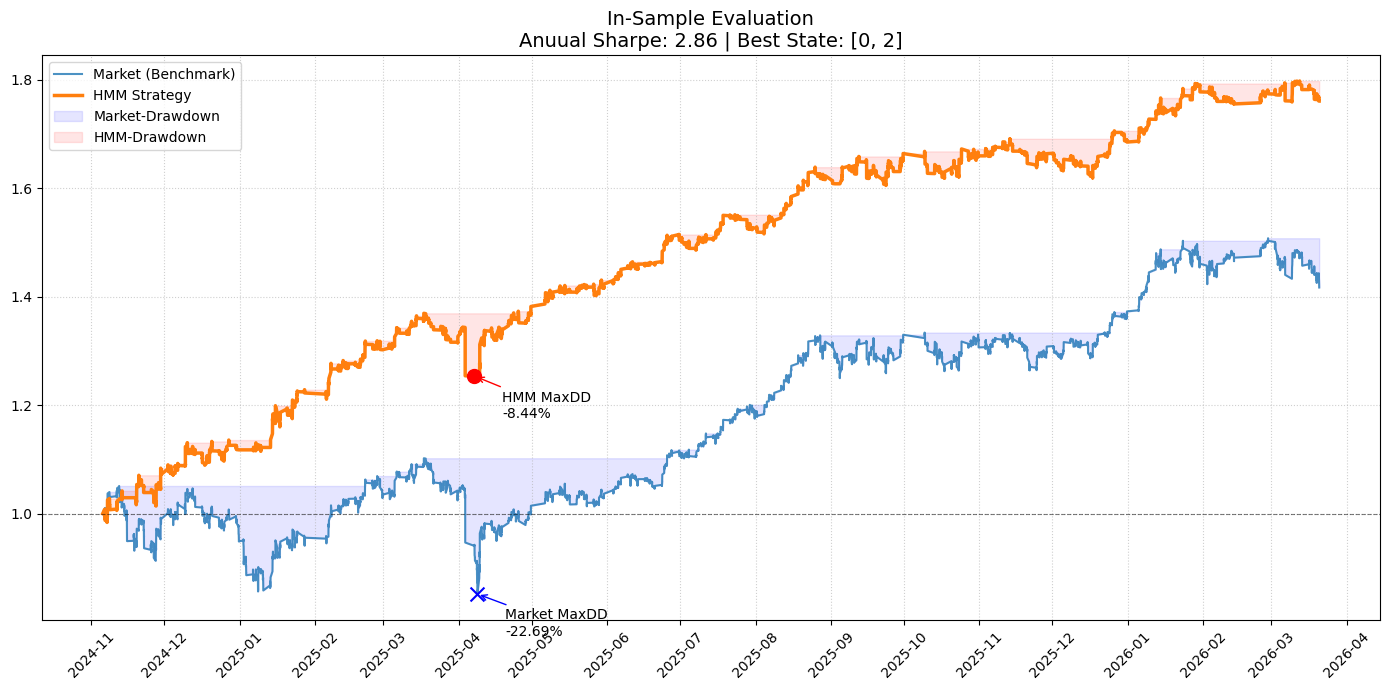

【市场基准】最大回撤: -66.83% | 发生时间: 2024-02-05 10:30:00
【HMM策略】最大回撤: -12.72% | 发生时间: 2022-12-30 13:00:00


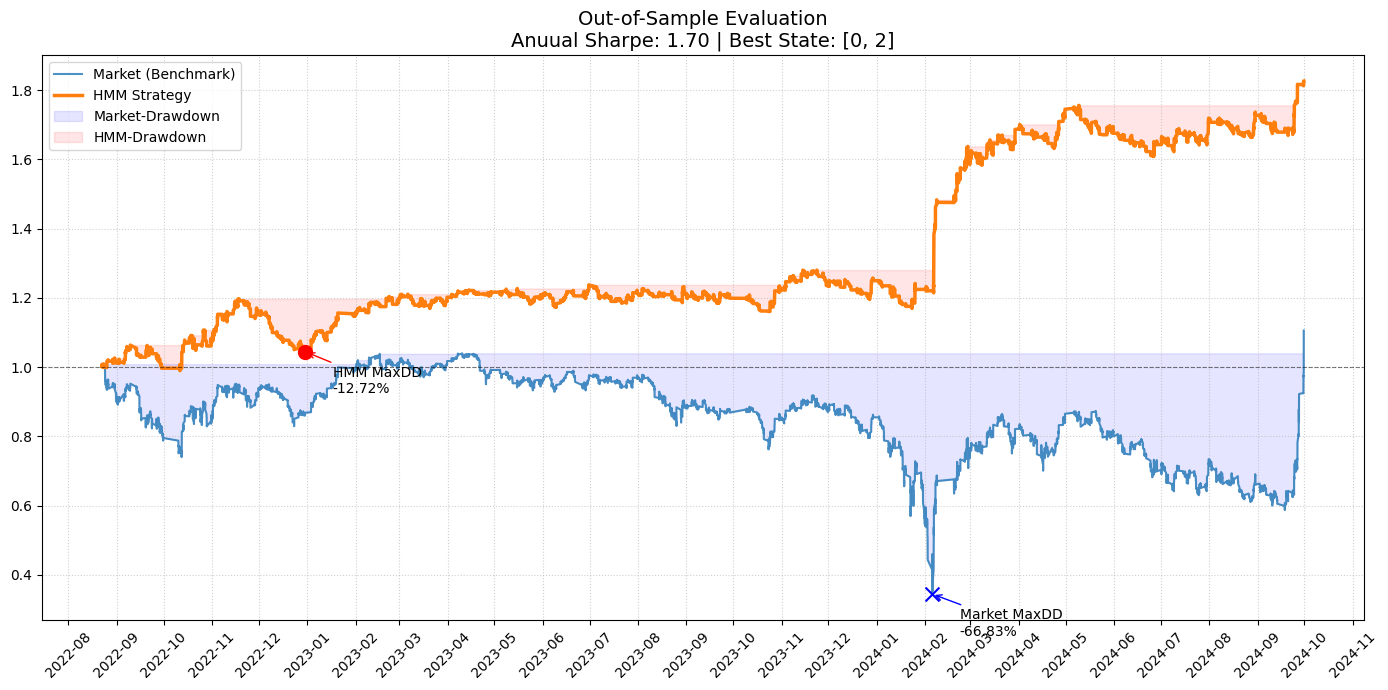

In [ ]:
def plot_backtest(df_input, title, use_state):
    # 1. 深拷贝并预处理，确保无警告
    df = df_input.copy()
    df.index = pd.to_datetime(df.index)
    
    # T时刻的仓位取T+1时刻的收益率
    # 对不同状态取不同仓位
    pos_market = np.ones_like(df['state'].values)
    pos_array = df['state'].isin(use_state).astype(float).values # state
    
    # 计算策略收益序列
    res_values = df['pct'].astype(float).values

    net_values, net_ret_array = cal_net_values(pos_array, res_values)
    market_values, market_ret_array = cal_net_values(pos_market, res_values)
    
    # df['net_ret_array'] = net_ret_array
    # net_ret_date = df['net_ret_array'].groupby(df.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率

    df['net_values'] = net_values
    net_ret_date = df['net_values'].groupby(df.index.date).last().diff()

    plot_dates = list(df.index)

    m_mdd_val, m_mdd_idx = calculate_mdd(market_values)
    s_mdd_val, s_mdd_idx = calculate_mdd(net_values)

    # 获取对应的日期（从 plot_dates 中提取）
    m_mdd_date = plot_dates[m_mdd_idx]
    s_mdd_date = plot_dates[s_mdd_idx]

    annual_sharpe = calculate_sharpe(net_ret_date)

    print(f"【市场基准】最大回撤: {m_mdd_val:.2%} | 发生时间: {m_mdd_date}")
    print(f"【HMM策略】最大回撤: {s_mdd_val:.2%} | 发生时间: {s_mdd_date}")

    plt.figure(figsize=(14, 7), dpi=100)
    
    # 使用你指定的蓝色和橙色
    plt.plot(plot_dates, market_values, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
    plt.plot(plot_dates, net_values, color='#ff7f0e', label='HMM Strategy', linewidth=2.5)
    
    # 绘制最大回撤区域（可选，更专业）
    market_peak = np.maximum.accumulate(market_values)
    strategy_peak = np.maximum.accumulate(net_values)
    plt.fill_between(plot_dates, market_values, market_peak, color='blue', alpha=0.1, label='Market-Drawdown')
    plt.fill_between(plot_dates, net_values, strategy_peak, color='red', alpha=0.1, label='HMM-Drawdown')

    # 起始点辅助线
    plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 标题与统计信息
    plt.title(f"{title}\nAnuual Sharpe: {annual_sharpe:.2f} | Best State: {use_state}", fontsize=14)
    
    # 坐标轴优化
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.scatter(m_mdd_date, market_values[m_mdd_idx], color='blue', s=100, marker='x', 
            label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)

    # 标记策略最大回撤点
    plt.scatter(s_mdd_date, net_values[s_mdd_idx], color='red', s=100, marker='o', 
                label=f'HMM MaxDD: {s_mdd_val:.2%}', zorder=5)
    plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
                xy=(m_mdd_date, market_values[m_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='blue'))
    plt.annotate(f'HMM MaxDD\n{s_mdd_val:.2%}', 
                xy=(s_mdd_date, net_values[s_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red'))
    plt.show()
# 状态总数
states = model.n_components
# 训练集确定best_state
best_state = df_train_plot.groupby('state')['close_log_ret_1p'].mean().idxmax()
print(best_state)
buy_state = [0,2]
plot_backtest(df_train_plot, "In-Sample Evaluation", buy_state)
plot_backtest(df_test_plot, "Out-of-Sample Evaluation", buy_state)

【市场基准】最大回撤: -22.69% | 发生时间: 2025-04-08 14:45:00
【HMM策略】最大回撤: -5.79% | 发生时间: 2025-04-03 14:45:00


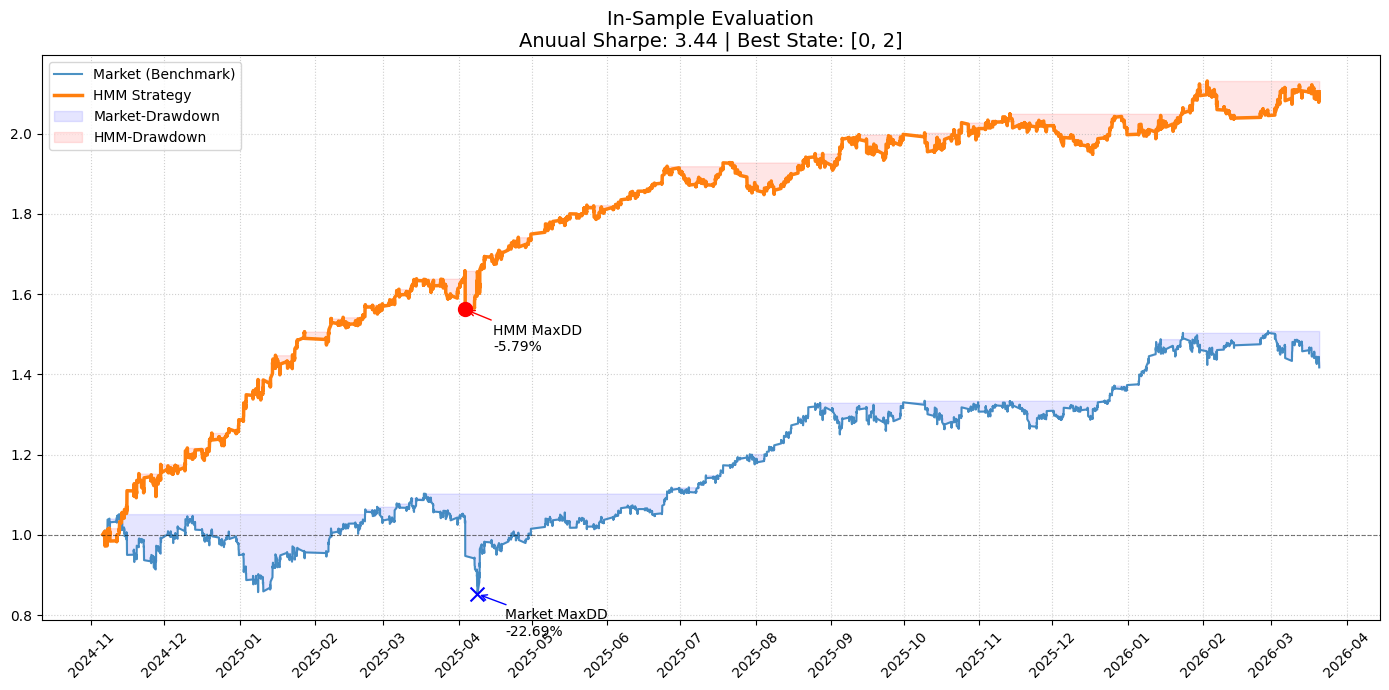

【市场基准】最大回撤: -66.83% | 发生时间: 2024-02-05 10:30:00
【HMM策略】最大回撤: -16.70% | 发生时间: 2022-12-30 13:00:00


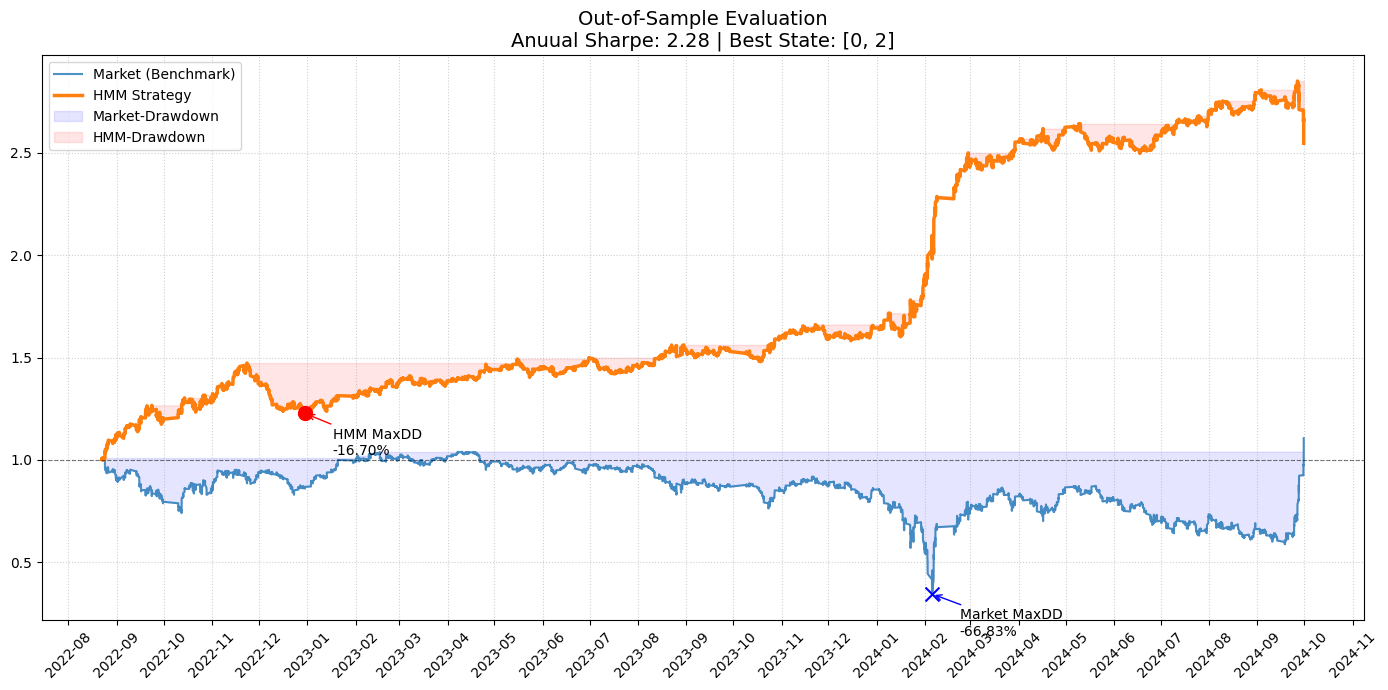

In [ ]:
def plot_backtest(df_input, title, use_state):
    # 1. 深拷贝并预处理，确保无警告
    df = df_input.copy()
    df.index = pd.to_datetime(df.index)
    
    # T时刻的仓位取T+1时刻的收益率
    # 对不同状态取不同仓位
    pos_market = np.ones_like(df['state'].values)
    pos_map = {3: -1, 2: 1, 1: -1, 0: 1}
    df['pos'] = df['state'].map(pos_map)
    pos_array = df['pos'].values
    
    # 计算策略收益序列
    res_values = df['pct'].astype(float).values

    net_values, net_ret_array = cal_net_values(pos_array, res_values)
    market_values, market_ret_array = cal_net_values(pos_market, res_values)
    # df['net_ret_array'] = net_ret_array
    # net_ret_date = df['net_ret_array'].groupby(df.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率

    df['net_values'] = net_values
    net_ret_date = df['net_values'].groupby(df.index.date).last().diff()


    plot_dates = list(df.index)

    m_mdd_val, m_mdd_idx = calculate_mdd(market_values)
    s_mdd_val, s_mdd_idx = calculate_mdd(net_values)

    # 获取对应的日期（从 plot_dates 中提取）
    m_mdd_date = plot_dates[m_mdd_idx]
    s_mdd_date = plot_dates[s_mdd_idx]

    annual_sharpe = calculate_sharpe(net_ret_date)

    print(f"【市场基准】最大回撤: {m_mdd_val:.2%} | 发生时间: {m_mdd_date}")
    print(f"【HMM策略】最大回撤: {s_mdd_val:.2%} | 发生时间: {s_mdd_date}")

    plt.figure(figsize=(14, 7), dpi=100)
    
    # 使用你指定的蓝色和橙色
    plt.plot(plot_dates, market_values, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
    plt.plot(plot_dates, net_values, color='#ff7f0e', label='HMM Strategy', linewidth=2.5)
    
    # 绘制最大回撤区域（可选，更专业）
    market_peak = np.maximum.accumulate(market_values)
    strategy_peak = np.maximum.accumulate(net_values)
    plt.fill_between(plot_dates, market_values, market_peak, color='blue', alpha=0.1, label='Market-Drawdown')
    plt.fill_between(plot_dates, net_values, strategy_peak, color='red', alpha=0.1, label='HMM-Drawdown')

    # 起始点辅助线
    plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 标题与统计信息
    plt.title(f"{title}\nAnuual Sharpe: {annual_sharpe:.2f} | Best State: {use_state}", fontsize=14)
    
    # 坐标轴优化
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.scatter(m_mdd_date, market_values[m_mdd_idx], color='blue', s=100, marker='x', 
            label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)

    # 标记策略最大回撤点
    plt.scatter(s_mdd_date, net_values[s_mdd_idx], color='red', s=100, marker='o', 
                label=f'HMM MaxDD: {s_mdd_val:.2%}', zorder=5)
    plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
                xy=(m_mdd_date, market_values[m_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='blue'))
    plt.annotate(f'HMM MaxDD\n{s_mdd_val:.2%}', 
                xy=(s_mdd_date, net_values[s_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red'))
    plt.show()
# 状态总数
states = model.n_components
# 训练集确定best_state
# best_state = df_train_plot.groupby('state')['f3'].mean().idxmax()
buy_state = [0,2]
plot_backtest(df_train_plot, "In-Sample Evaluation", buy_state)
plot_backtest(df_test_plot, "Out-of-Sample Evaluation", buy_state)

## 3.5 保存数据

In [34]:
df_test = df_test_plot.copy()
df_test.index = pd.to_datetime(df_test.index)

# T时刻的仓位取T+1时刻的收益率
# 对不同状态取不同仓位
pos_market = np.ones_like(df_test['state'].values)
pos_map = {3: 1.0, 2: -1.0, 1: 1, 0: -1}
df_test['pos'] = df_test['state'].map(pos_map)
pos_array = df_test['pos'].values
# 计算策略收益序列
res_values = df_test['pct'].astype(float).values
print("res:", res_values)
net_values, _ = cal_net_values(pos_array, res_values)
market_values, _ = cal_net_values(pos_market, res_values)
df_test["HMM-net"] = net_values
df_test["market-net"] = market_values
df_test.to_csv("../data/HMM_model_im.csv")



res: [0.00262997 0.00030412 0.00193821 ... 0.         0.         0.11951633]
